In [1]:
#import Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
# Statistics and Regression

from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

In [3]:
# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Datasets/market_and_sales.csv")

In [8]:
# View first rows
print(df.head())

     TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829
3  83.0  30.020028      6.922304  298.246340
4  15.0   8.437408      1.405998   56.594181


In [9]:
# Dataset information
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(4572, 4)


In [10]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB
None


In [11]:
#Check and handle missing values

print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64


In [12]:
df = df.dropna()


In [13]:
print("\nDataset Shape After Cleaning:")
print(df.shape)


Dataset Shape After Cleaning:
(4546, 4)


In [14]:
#Descriptive statistics
print(df.describe())

                TV        Radio  Social_Media        Sales
count  4546.000000  4546.000000   4546.000000  4546.000000
mean     54.062912    18.157533      3.323473   192.413332
std      26.104942     9.663260      2.211254    93.019873
min      10.000000     0.000684      0.000031    31.199409
25%      32.000000    10.555355      1.530822   112.434612
50%      53.000000    17.859513      3.055565   188.963678
75%      77.000000    25.640603      4.804919   272.324236
max     100.000000    48.871161     13.981662   364.079751


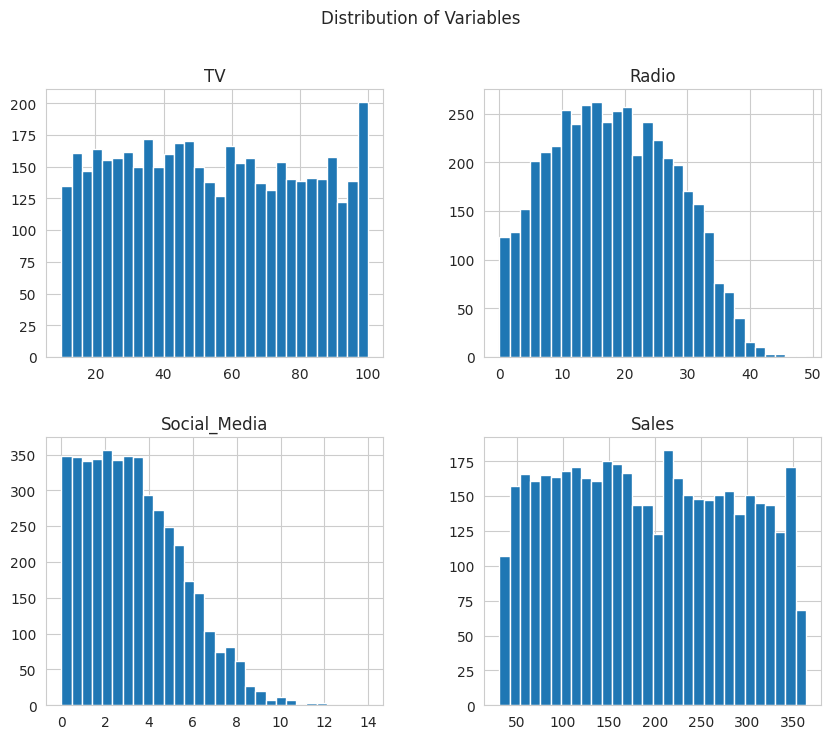

In [15]:
#Exploratory Data Analysis

df.hist(bins=30, figsize=(10, 8))
plt.suptitle("Distribution of Variables")
plt.show()

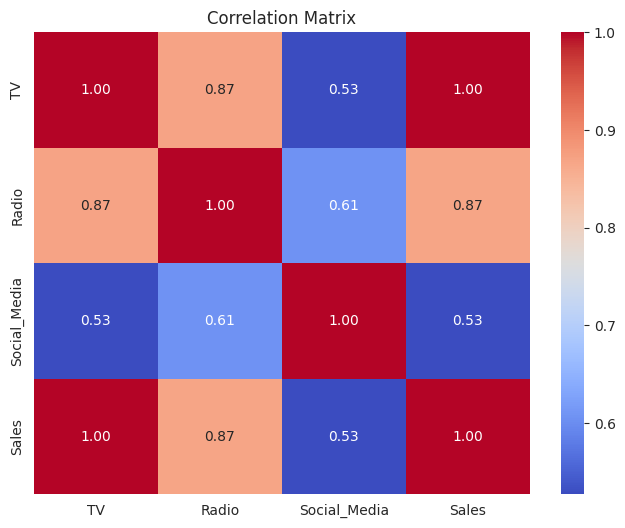

In [16]:
#Correlation Matrix

plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()


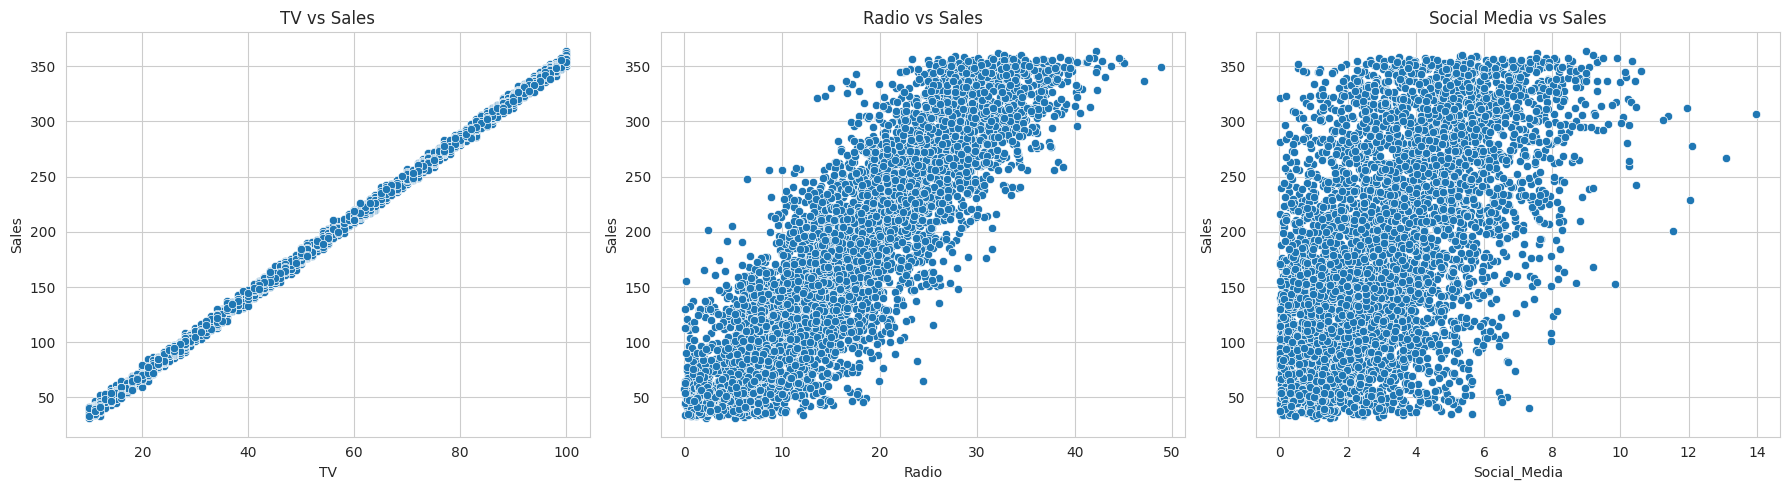

In [17]:
#Scatterplots

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x="TV", y="Sales", ax=axes[0])
axes[0].set_title("TV vs Sales")

sns.scatterplot(data=df, x="Radio", y="Sales", ax=axes[1])
axes[1].set_title("Radio vs Sales")

sns.scatterplot(data=df, x="Social_Media", y="Sales", ax=axes[2])
axes[2].set_title("Social Media vs Sales")

plt.tight_layout()
plt.show()

In [18]:
#Find most correlated predictor
corr_with_sales = df.corr()["Sales"].drop("Sales")

print("Correlation with Sales:")
print(corr_with_sales.sort_values(ascending=False))


Correlation with Sales:
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64


In [19]:
#Build OLS regression
#define X and y
X = df[["TV"]]
y = df["Sales"]

# Add constant
X = sm.add_constant(X)

In [20]:
#Fit model
model = sm.OLS(y, X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Thu, 25 Jun 2026   Prob (F-statistic):               0.00
Time:                        09:55:25   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

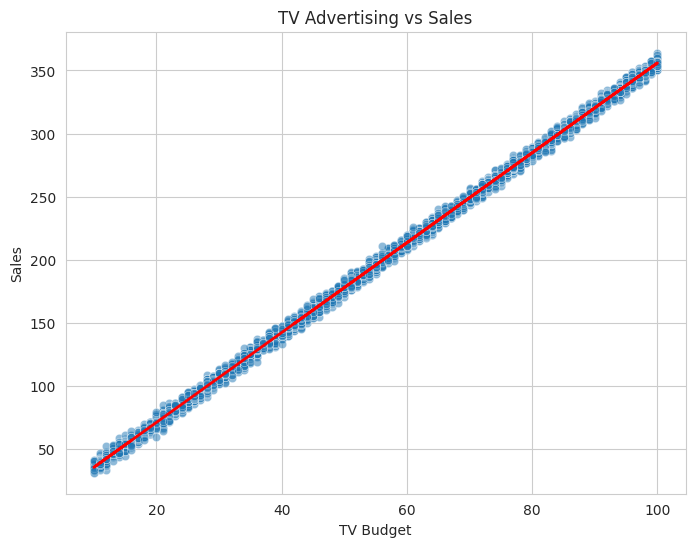

In [21]:
#Regression line visualization
#Plot regression line
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df["TV"],
    y=df["Sales"],
    alpha=0.5
)

plt.plot(
    df["TV"],
    model.predict(X),
    color="red",
    linewidth=2
)

plt.title("TV Advertising vs Sales")
plt.xlabel("TV Budget")
plt.ylabel("Sales")

plt.show()

In [22]:
#diagnostic tests
#obtain residuals
predictions = model.predict(X)

residuals = y - predictions

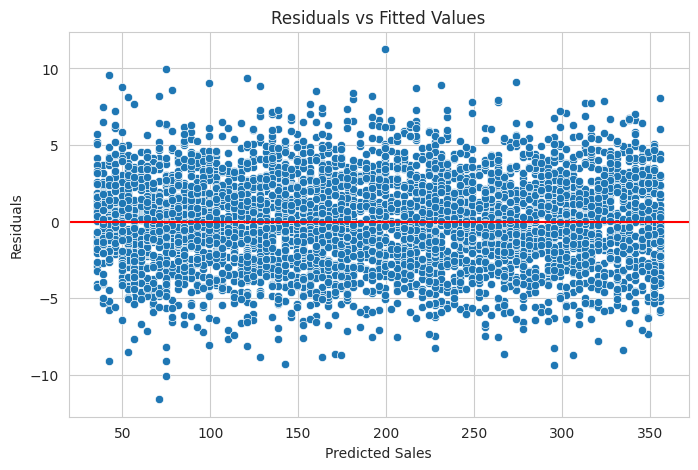

In [23]:
#linearity check

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=predictions,
    y=residuals
)

plt.axhline(0, color="red")

plt.title("Residuals vs Fitted Values")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.show()

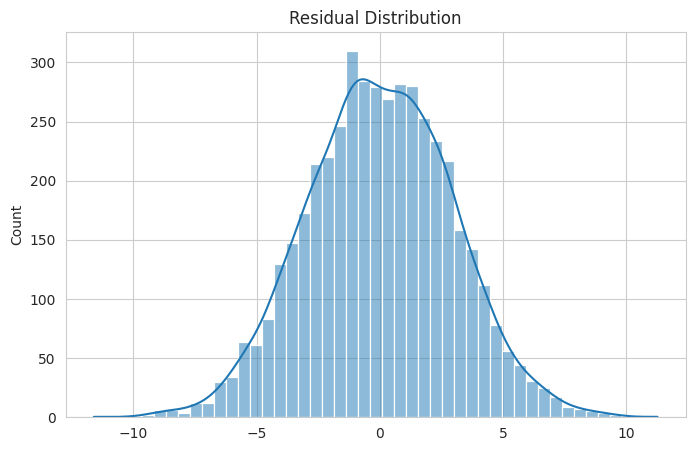

In [24]:
#Normality check
#Histogram
plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")
plt.show()


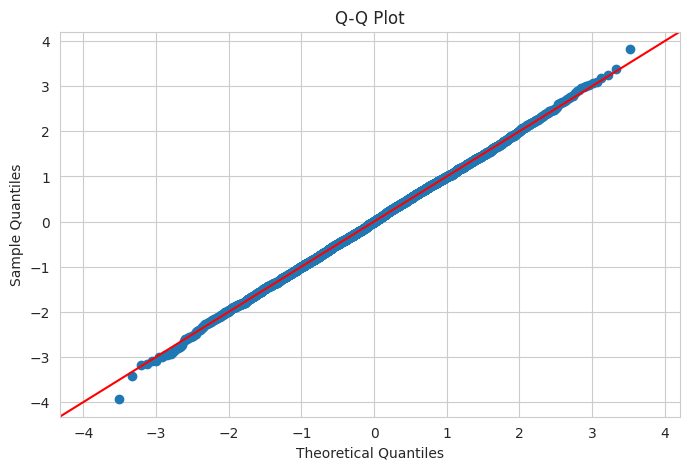

In [25]:
#QQ plot
sm.qqplot(
    residuals,
    line="45",
    fit=True
)

plt.title("Q-Q Plot")
plt.show()

In [26]:
#Shapiro-Wilk test
stat, p = stats.shapiro(residuals)

print("Shapiro-Wilk p-value:", p)

if p > 0.05:
    print("Residuals are approximately normal.")
else:
    print("Residuals are not normally distributed.")


Shapiro-Wilk p-value: 0.9136259165210332
Residuals are approximately normal.


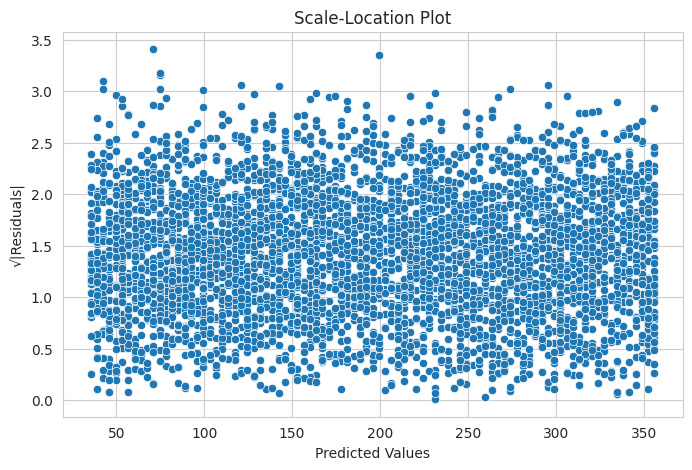

In [27]:
#Homoscedasticity check
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=predictions,
    y=np.sqrt(np.abs(residuals))
)

plt.title("Scale-Location Plot")
plt.xlabel("Predicted Values")
plt.ylabel("√|Residuals|")

plt.show()

In [28]:
#Breusch-Pagan test
bp_test = het_breuschpagan(
    residuals,
    X
)

labels = [
    "LM Statistic",
    "LM-Test p-value",
    "F Statistic",
    "F-Test p-value"
]

print(dict(zip(labels, bp_test)))


{'LM Statistic': np.float64(5.9268768091813584e-05), 'LM-Test p-value': np.float64(0.9938574496969989), 'F Statistic': np.float64(5.924269371982943e-05), 'F-Test p-value': np.float64(0.993859138829823)}


In [29]:
#Model Performance Metric
#Extract key metrics

print("R-squared:", model.rsquared)
print("Adjusted R-squared:", model.rsquared_adj)
print("Intercept:", model.params["const"])
print("TV Coefficient:", model.params["TV"])
print("TV p-value:", model.pvalues["TV"])


R-squared: 0.998994984518024
Adjusted R-squared: 0.9989947633438423
Intercept: -0.13249254000259134
TV Coefficient: 3.5615140946411747
TV p-value: 0.0


Model Interpretation
TV advertising has the strongest correlation with Sales.
The coefficient of TV indicates the average increase in Sales for every one-unit increase in TV advertising expenditure.
The p-value is expected to be much smaller than 0.05, indicating a statistically significant relationship.
The R² value explains the percentage of Sales variability captured by TV advertising spend.

Marketing Recommendation
Based on the analysis, TV advertising delivers the strongest impact on Sales and exhibits the highest correlation among all marketing channels. The regression model indicates that increasing investment in TV advertising is likely to generate the largest increase in Sales. Therefore, future marketing budgets should prioritize TV campaigns while using Radio and Social Media as supporting channels.


